# N-body subhalo orbits: radius and period evolution

Orbital radius and radial period per snapshot, for the two raw Du+24 runs and a selection of DASH runs.

Neither set has Chandrasekhar dynamical friction: in both, the host is a static analytic potential with its centre pinned at the origin. Orbital decay under those conditions — stripped material torquing the bound remnant — is dynamical self-friction, measured on DASH by [Miller, van den Bosch, Green & Ogiya (2020)](https://arxiv.org/abs/2001.06489).

In [1]:
import os
import pickle

import h5py
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('paper.mplstyle')
%matplotlib inline

# Petroff (2021) accessible palette, from the style's cycle. Hue tracks the orbit:
# warm for the radial runs (R_p/R_a ~ 1/20), cool for the more circular ones
# (~1/5-1/7). Dataset is carried by marker and line style, not colour.
RADIAL = ['bd1f01', 'e76300', 'ffa90e']
CIRCULAR = ['3f90da', '832db6', '92dadd']

DU24 = 'etc/du24_nbody/simulationData_xc_0.7_ratio_%s_alpha_1.0_beta_3.0_gamma_1.0.hdf5'
DU24_ORBITS = [('1/5', '0.2', '#' + CIRCULAR[0]), ('1/20', '0.05', '#' + RADIAL[0])]


def load_du24(ratio):
    """Raw Du+24 series. Some scalar dataset names carry trailing blanks."""
    with h5py.File(DU24 % ratio, 'r') as f:
        d = {k.strip(): f[k][()] for k in f.keys()}
    return d


def extrema(t, r):
    """Local maxima and minima of r(t), parabola-refined onto sub-snapshot times
    so the period is not quantized by the snapshot cadence (Du+24: 0.0998 Gyr,
    ~3% of a radial period).

    Both datasets launch the subhalo at rest at apocentre, so r[0] is the k=0
    apocentre and is included unrefined -- a three-point fit has no left
    neighbour there, and dropping it would normalize every ratio to the k=1
    orbit, after the first pericentre passage has already stripped the subhalo.
    """
    def refine(sign):
        out = []
        y = sign * r
        if y[0] > y[1]:
            out.append((t[0], r[0]))
        for k in range(1, len(y) - 1):
            if y[k] >= y[k - 1] and y[k] > y[k + 1]:
                den = y[k - 1] - 2. * y[k] + y[k + 1]
                dk = 0.5 * (y[k - 1] - y[k + 1]) / den if den != 0. else 0.
                out.append((t[k] + dk * (t[k + 1] - t[k]),
                            sign * (y[k] - 0.25 * (y[k - 1] - y[k + 1]) * dk)))
        return np.array(out).reshape(-1, 2)
    return refine(1.), refine(-1.)

## The data

Du+24's `orbitalRadius` is the bound remnant's distance from the fixed host centre, in Mpc. Both runs share a host ($M_{\rm vir} = 10^{12}\,M_\odot$, $c_h = 11.1$) and a $10^9\,M_\odot$ NFW subhalo, differing only in $R_p/R_a$.

DASH records the subhalo centre-of-mass position and velocity per snapshot (in $r_{\rm vir,h}$ and $v_{\rm vir,h}$), plus $f_b$. Times are already in units of the radial period $T_r$ via the `nTr` snapshot index. Within one DASH orbit the host ($c_h = 10$), the mass ratio ($M_{\rm vir,h}/M_{\rm vir,s} = 1000$), the particle count, the softening and the orbit itself are all identical across runs; only $c_s$ changes.

In [2]:
idx = pickle.load(open('etc/dash/dash_index.pkl', 'rb'))


def dash_run(cs, xc, eta, ch=10.):
    for r in idx:
        if all(abs(r[k] - v) < 1e-6 for k, v in
               (('ch', ch), ('cs', cs), ('xc', xc), ('eta', eta))):
            return r
    raise KeyError((cs, xc, eta, ch))


def load_dash(cs, xc, eta):
    """Orbital radius (r_vir,h) and f_b on a t/T_r grid."""
    rec = dash_run(cs, xc, eta)
    dat = np.loadtxt(rec['file'])
    r = np.linalg.norm(dat[:, 1:4], axis=1)
    return np.arange(len(r)) / rec['nTr'], r, dat[:, 7], rec


# xc=1.15/eta=0.2 is R_p/R_a = 1/24, alongside Du+24's 1/20; xc=0.87/eta=0.5 is
# 1/7, alongside Du+24's 1/5. Colours follow those two regimes.
DASH_SEL = [('radial, $c_s=12.5$', 12.5, 1.15, 0.2, '#' + RADIAL[1]),
            ('radial, $c_s=25$', 25.0, 1.15, 0.2, '#' + RADIAL[2]),
            ('circular, $c_s=12.5$', 12.5, 0.87, 0.5, '#' + CIRCULAR[1]),
            ('circular, $c_s=25$', 25.0, 0.87, 0.5, '#' + CIRCULAR[2])]

du = {lab: load_du24(ratio) for lab, ratio, _ in DU24_ORBITS}
dash = {lab: load_dash(cs, xc, eta) for lab, cs, xc, eta, _ in DASH_SEL}

## Apocentre and period

Per orbit $k$, measured at apocentre; the period is the apocentre-to-apocentre time.

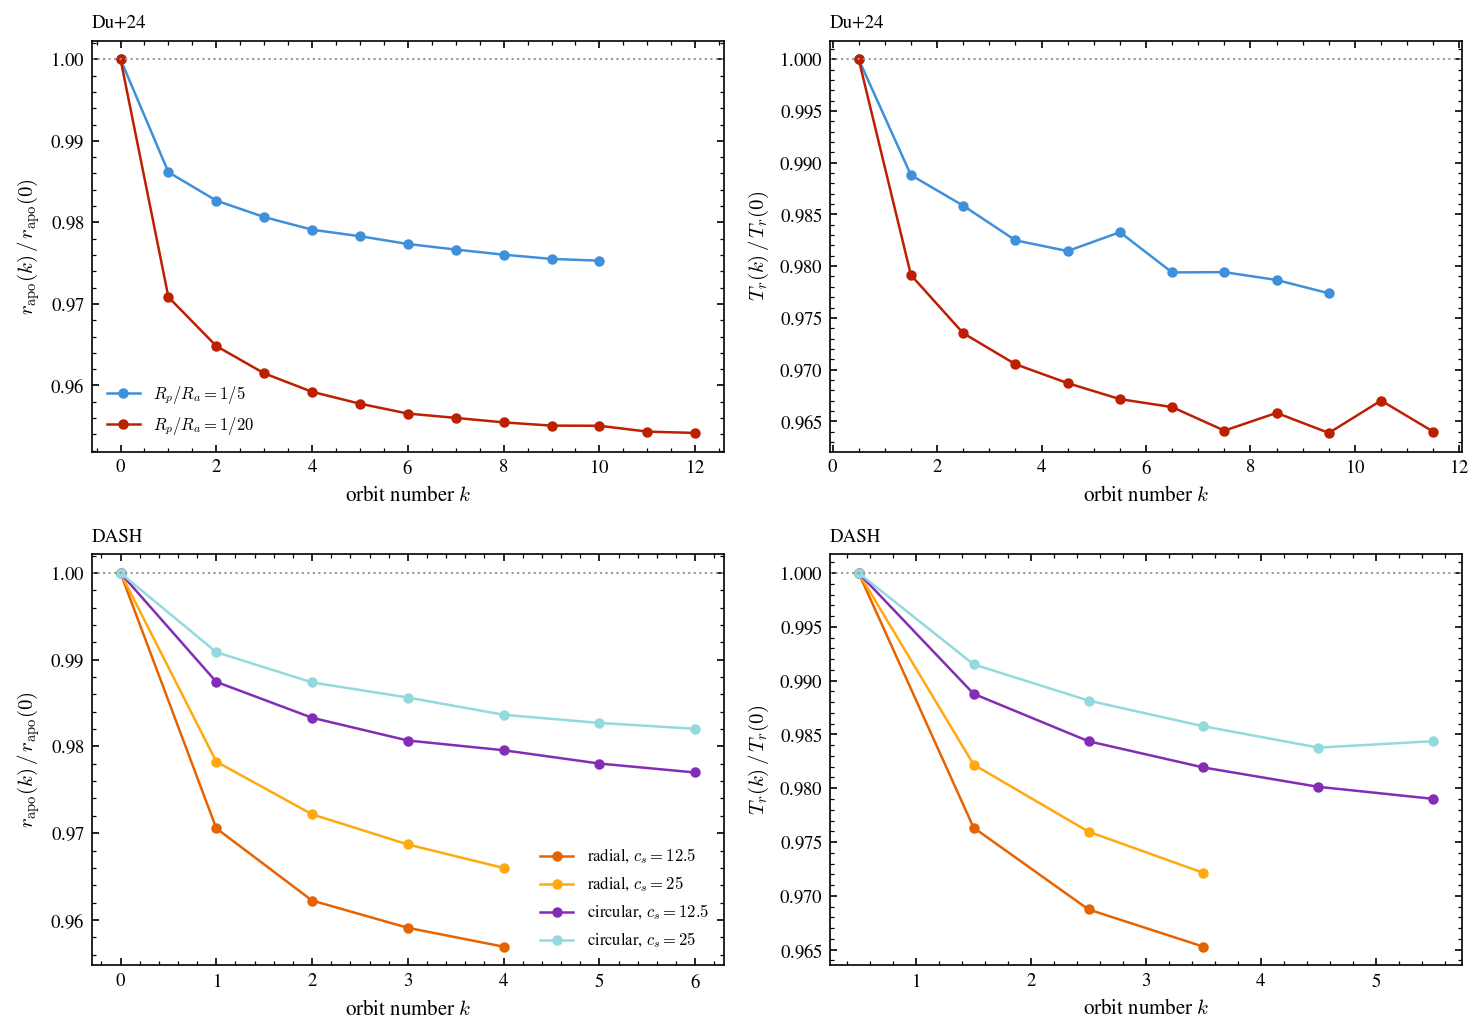

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for lab, ratio, color in DU24_ORBITS:
    d = du[lab]
    apo, _ = extrema(d['time'], d['orbitalRadius'])
    ta, ra = apo[:, 0], apo[:, 1]
    k = np.arange(len(ra))
    T = np.diff(ta)
    axes[0, 0].plot(k, ra / ra[0], '-o', ms=4, color=color,
                    label=r'$R_p/R_a=%s$' % lab)
    axes[0, 1].plot(k[:-1] + 0.5, T / T[0], '-o', ms=4, color=color)

for lab, cs, xc, eta, color in DASH_SEL:
    t, r, fb, rec = dash[lab]
    apo, _ = extrema(t, r)
    ta, ra = apo[:, 0], apo[:, 1]
    k = np.arange(len(ra))
    T = np.diff(ta)
    axes[1, 0].plot(k, ra / ra[0], '-o', ms=4, color=color, label=lab)
    axes[1, 1].plot(k[:-1] + 0.5, T / T[0], '-o', ms=4, color=color)

for i, name in enumerate(('Du+24', 'DASH')):
    axes[i, 0].set_ylabel(r'$r_{\rm apo}(k)\,/\,r_{\rm apo}(0)$')
    axes[i, 1].set_ylabel(r'$T_r(k)\,/\,T_r(0)$')
    axes[i, 0].legend(fontsize=8)
    for ax in axes[i]:
        ax.set_xlabel(r'orbit number $k$')
        ax.set_title(name, loc='left', fontsize=9)
        ax.axhline(1., ls=':', lw=1, color='0.6')

fig.tight_layout()
plt.show()

## The orbits

The underlying trajectories, in each dataset's native units. Open circles mark apocentres, filled squares pericentres.

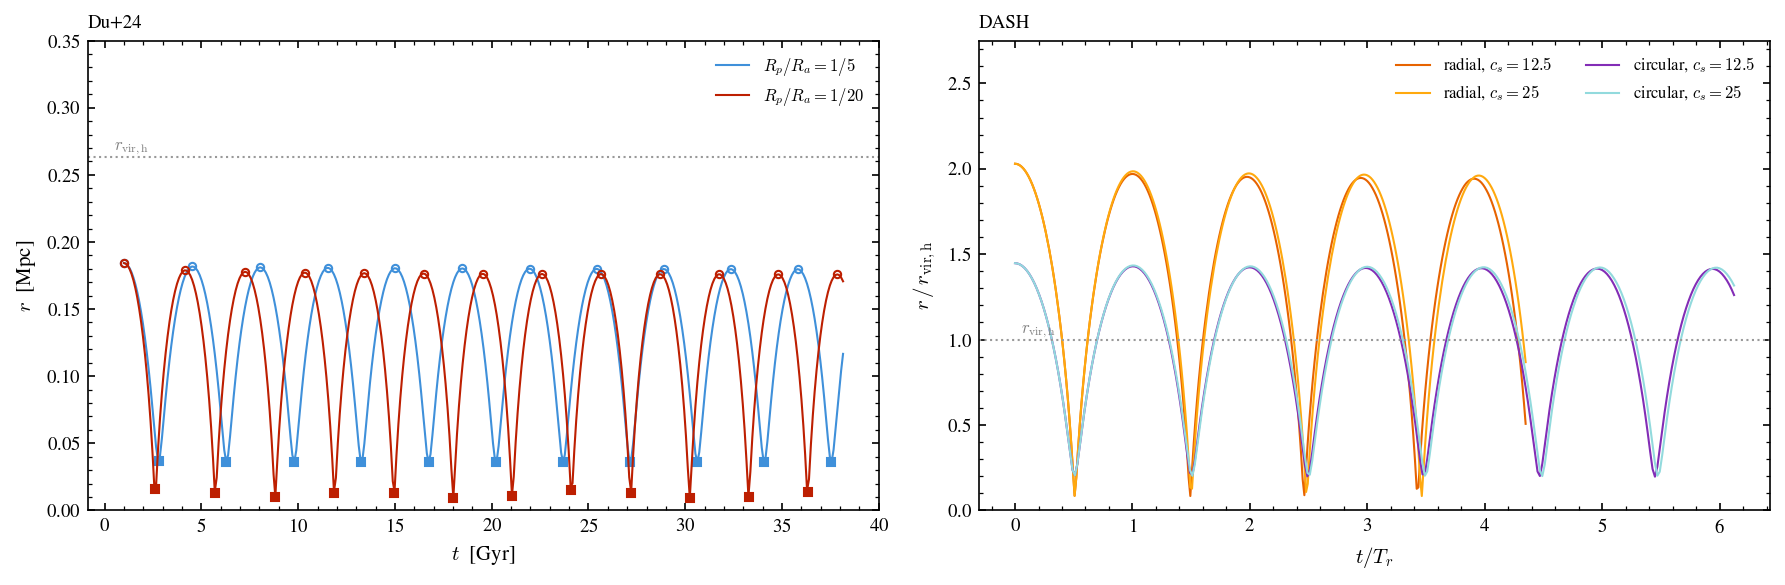

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lab, ratio, color in DU24_ORBITS:
    d = du[lab]
    t, r = d['time'], d['orbitalRadius']
    apo, peri = extrema(t, r)
    axes[0].plot(t, r, '-', lw=1., color=color, label=r'$R_p/R_a = %s$' % lab)
    axes[0].plot(apo[:, 0], apo[:, 1], 'o', ms=3.5, mfc='none', color=color)
    axes[0].plot(peri[:, 0], peri[:, 1], 's', ms=3.5, color=color)
axes[0].axhline(du['1/5']['RvirHost0'], ls=':', lw=1, color='0.6')
axes[0].text(0.5, du['1/5']['RvirHost0'], r'$r_{\rm vir,h}$', va='bottom',
             fontsize=8, color='0.5')
axes[0].set_ylim(0., 0.35)  # headroom so the legend clears r_vir,h
axes[0].set_xlabel(r'$t$  [Gyr]')
axes[0].set_ylabel(r'$r$  [Mpc]')
axes[0].set_title('Du+24', loc='left', fontsize=9)
axes[0].legend(fontsize=8, loc='upper right')

for lab, cs, xc, eta, color in DASH_SEL:
    t, r, fb, rec = dash[lab]
    axes[1].plot(t, r, '-', lw=1., color=color, label=lab)
axes[1].axhline(1., ls=':', lw=1, color='0.6')
axes[1].text(0.05, 1., r'$r_{\rm vir,h}$', va='bottom', fontsize=8, color='0.5')
axes[1].set_ylim(0., 2.75)
axes[1].set_xlabel(r'$t/T_r$')
axes[1].set_ylabel(r'$r\,/\,r_{\rm vir,h}$')
axes[1].set_title('DASH', loc='left', fontsize=9)
axes[1].legend(fontsize=8, loc='upper right', ncol=2)

fig.tight_layout()
plt.show()

## Decay against mass loss

Left: apocentre radius against the mass shed since infall, one point per apocentre. Right: the same runs as per-orbit rates — the fractional apocentre decay between consecutive apocentres, $-\Delta \ln r_{\rm apo}$, against the fractional mass shed over that orbit, $-\Delta \ln m$, with a least-squares power law through all six.

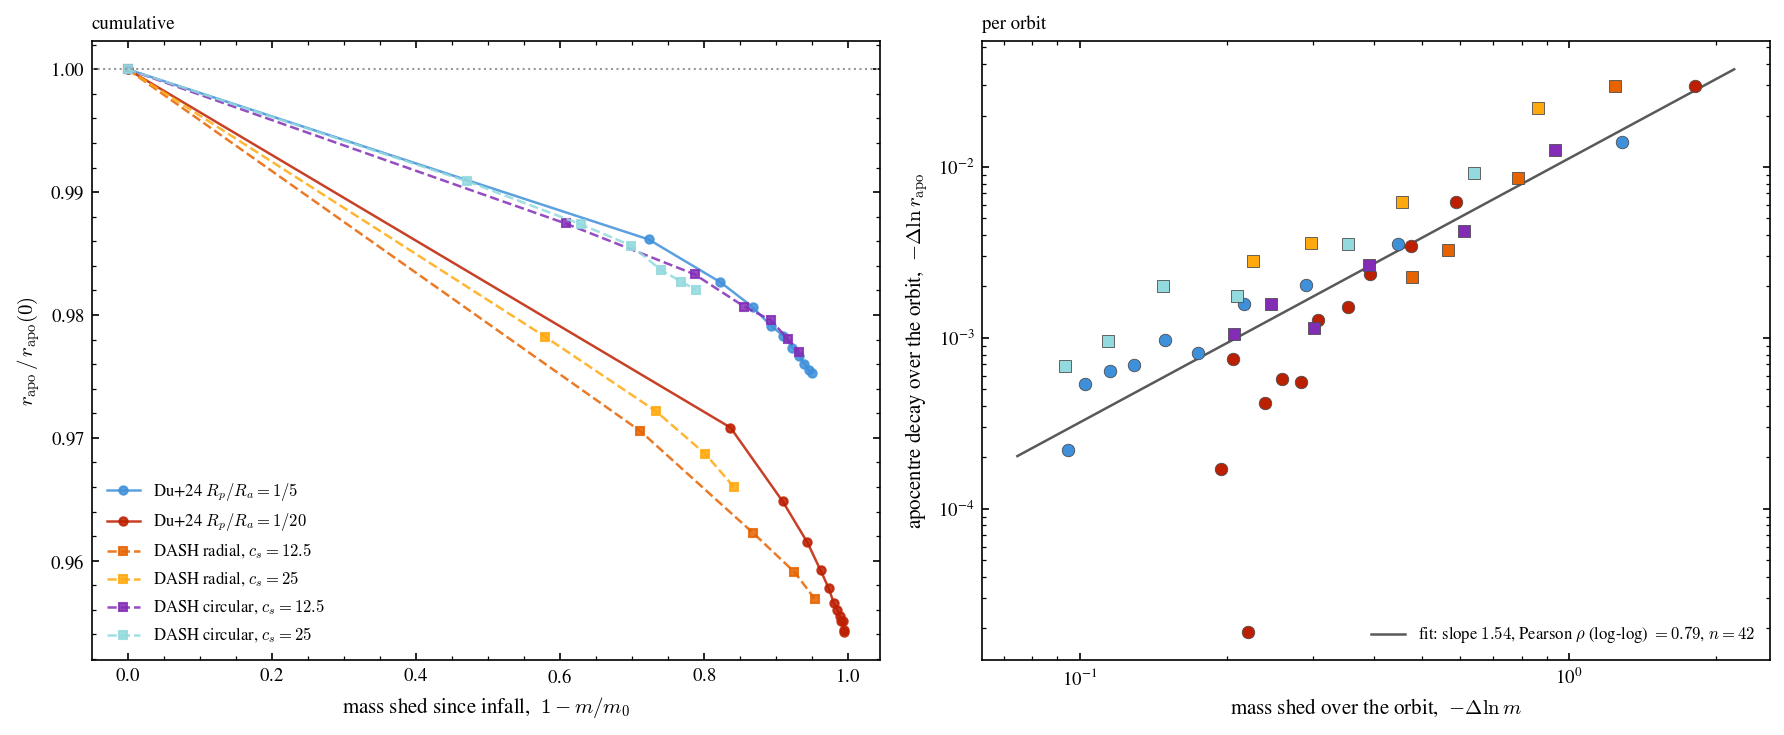

In [5]:
#---apocentre radius and bound mass at each apocentre, all six runs
series = []
for lab, ratio, color in DU24_ORBITS:
    d = du[lab]
    apo, _ = extrema(d['time'], d['orbitalRadius'])
    ka = np.clip(np.searchsorted(d['time'], apo[:, 0]), 0, len(d['time']) - 1)
    series.append((r'Du+24 $R_p/R_a=%s$' % lab, color, 'o', '-', apo[:, 1],
                   d['boundMass'][ka]))
for lab, cs, xc, eta, color in DASH_SEL:
    t, r, fb, rec = dash[lab]
    apo, _ = extrema(t, r)
    ka = np.clip(np.round(apo[:, 0] * rec['nTr']).astype(int), 0, len(fb) - 1)
    series.append(('DASH ' + lab, color, 's', '--', apo[:, 1], fb[ka]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

X, Y = [], []
for lab, color, mk, ls, ra, m in series:
    axes[0].plot(1. - m / m[0], ra / ra[0], ls, marker=mk, ms=4, color=color,
                 alpha=0.85, label=lab)
    dlnr = -np.diff(np.log(ra))
    dlnm = -np.diff(np.log(m))
    axes[1].plot(dlnm, dlnr, mk, ms=6, color=color, mec='0.3', mew=0.4)
    X.append(dlnm)
    Y.append(dlnr)

X, Y = np.concatenate(X), np.concatenate(Y)
ok = (X > 0.) & (Y > 0.)
lx, ly = np.log10(X[ok]), np.log10(Y[ok])
slope, icpt = np.polyfit(lx, ly, 1)
rho = np.corrcoef(lx, ly)[0, 1]
xf = np.array([0.8 * X[ok].min(), 1.2 * X[ok].max()])
axes[1].plot(xf, 10.**icpt * xf**slope, '-', lw=1.2, color='0.35', zorder=0,
             label=r'fit: slope $%.2f$, Pearson $\rho$ (log-log) $=%.2f$, $n=%d$'
                   % (slope, rho, ok.sum()))

axes[0].set_xlabel(r'mass shed since infall,  $1 - m/m_0$')
axes[0].set_ylabel(r'$r_{\rm apo}\,/\,r_{\rm apo}(0)$')
axes[0].axhline(1., ls=':', lw=1, color='0.6')
axes[0].set_title('cumulative', loc='left', fontsize=9)
axes[0].legend(fontsize=8)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(r'mass shed over the orbit,  $-\Delta \ln m$')
axes[1].set_ylabel(r'apocentre decay over the orbit,  $-\Delta \ln r_{\rm apo}$')
axes[1].set_title('per orbit', loc='left', fontsize=9)
axes[1].legend(fontsize=8, loc='lower right')

fig.tight_layout()
plt.show()

### Controlled comparison: only $c_s$ varies

Apocentre and period decay after $k = 4$ orbits, against the subhalo concentration, for DASH's full $c_s$ ladder at each orbit. Within a curve the host, the mass ratio, the particle count, the softening and the orbit are all identical; $c_s$ is the only thing that changes. Both quantities are a percentage decay relative to $k = 0$, so they share the axis.

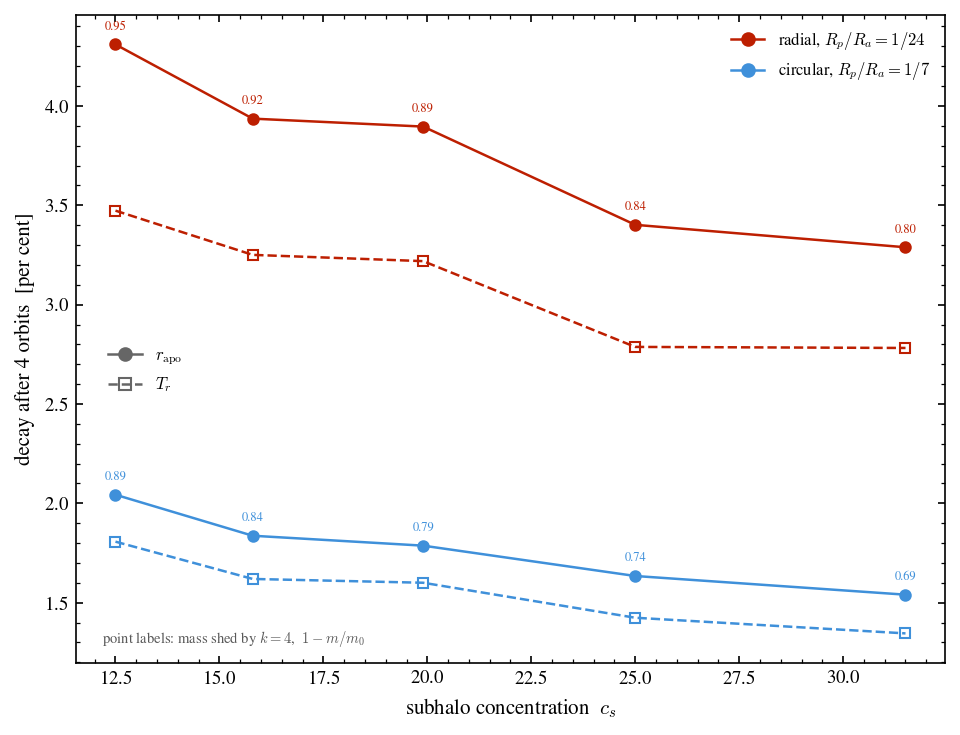

In [6]:
CS_LADDER = [12.5, 15.8, 19.9, 25.0, 31.5]
K_CMP = 4  # deepest orbit both ladders reach
CONTROLLED = [('radial, $R_p/R_a=1/24$', 1.15, 0.2, '#' + RADIAL[0]),
              ('circular, $R_p/R_a=1/7$', 0.87, 0.5, '#' + CIRCULAR[0])]

fig, ax = plt.subplots(figsize=(6.5, 5))

for oname, xc, eta, color in CONTROLLED:
    dec_r, dec_T, shed = [], [], []
    for cs in CS_LADDER:
        t, r, fb, rec = load_dash(cs, xc, eta)
        apo, _ = extrema(t, r)
        ta, ra = apo[:, 0], apo[:, 1]
        T = np.diff(ta)
        ka = np.clip(np.round(ta * rec['nTr']).astype(int), 0, len(fb) - 1)
        dec_r.append(100. * (1. - ra[K_CMP] / ra[0]))
        dec_T.append(100. * (1. - T[K_CMP - 1] / T[0]))
        shed.append(1. - fb[ka[K_CMP]] / fb[ka[0]])
    ax.plot(CS_LADDER, dec_r, '-o', ms=5, color=color)
    ax.plot(CS_LADDER, dec_T, '--s', ms=5, color=color, mfc='none')
    for cs, y, s in zip(CS_LADDER, dec_r, shed):
        ax.annotate('%.2f' % s, (cs, y), textcoords='offset points',
                    xytext=(0, 7), ha='center', fontsize=6, color=color)

# the annotations are a mass fraction while the y-axis is a percentage; say so
ax.text(0.03, 0.03, r'point labels: mass shed by $k=%d$,  $1 - m/m_0$' % K_CMP,
        transform=ax.transAxes, fontsize=7, color='0.35')

# colour carries the orbit, line style the quantity -- one legend each. The
# quantity key sits in the empty band between the two orbits' curves.
line = mpl.lines.Line2D
orbits = [line([], [], color=c, marker='o', ls='-', label=n)
          for n, _, _, c in CONTROLLED]
kinds = [line([], [], color='0.4', marker='o', ls='-', label=r'$r_{\rm apo}$'),
         line([], [], color='0.4', marker='s', ls='--', mfc='none', label=r'$T_r$')]
ax.add_artist(ax.legend(handles=orbits, fontsize=8, loc='upper right'))
ax.legend(handles=kinds, fontsize=8, loc='center left', bbox_to_anchor=(0.02, 0.45))

ax.set_xlabel(r'subhalo concentration  $c_s$')
ax.set_ylabel(r'decay after %d orbits  [per cent]' % K_CMP)
fig.tight_layout()
plt.show()